Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

Create Time Series Data

In [2]:
# ==============================
# 1. CREATE TIME SERIES DATA
# ==============================
months = pd.date_range(start="2024-01-01", periods=30, freq="ME")

sales = np.array([
    120,130,125,140,150,160,
    170,165,180,190,200,210,
    220,235,230,245,260,270,
    285,280,295,310,320,340,
    350,360,375,390,405,420
])

df = pd.DataFrame({"date": months, "sales": sales})

df.head()

,date,sales
0,2024-01-31,120
1,2024-02-29,130
2,2024-03-31,125
3,2024-04-30,140
4,2024-05-31,150


Feature Engineering

In [3]:
# ==============================
# 2. FEATURE ENGINEERING
# ==============================
df["time_index"] = np.arange(len(df))
df["month"] = df["date"].dt.month

df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)

df.head()

,date,sales,time_index,month,sin_month,cos_month
0,2024-01-31,120,0,1,0.500000,8.660254e-01
1,2024-02-29,130,1,2,0.866025,5.000000e-01
2,2024-03-31,125,2,3,1.000000,6.123234e-17
3,2024-04-30,140,3,4,0.866025,-5.000000e-01
4,2024-05-31,150,4,5,0.500000,-8.660254e-01


Train-Test Split

In [4]:
# ==============================
# 3. TRAIN / TEST SPLIT
# ==============================
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

features = ["time_index", "sin_month", "cos_month"]

X_train = train[features]
y_train = train["sales"]

X_test = test[features]
y_test = test["sales"]

Model Training

In [5]:
# ==============================
# 4. MODEL TRAINING
# ==============================
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Predictions

In [6]:
# ==============================
# 5. PREDICTIONS
# ==============================
y_pred = model.predict(X_test)

y_pred

array([337.60301891, 346.95922948, 355.71444022, 364.03942916,
       372.2202519 , 380.5815933 ])

Evaluation

In [7]:
# ==============================
# 6. EVALUATION
# ==============================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMODEL PERFORMANCE")
print("------------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))


MODEL PERFORMANCE
------------------
MAE  : 23.81
RMSE : 25.81


Future Forecast

In [8]:
# ==============================
# 7. FUTURE FORECAST (12 MONTHS)
# ==============================
future_dates = pd.date_range(start=df["date"].iloc[-1], periods=13, freq="ME")[1:]

future_df = pd.DataFrame({"date": future_dates})

future_df["time_index"] = np.arange(len(df), len(df) + 12)
future_df["month"] = future_df["date"].dt.month

future_df["sin_month"] = np.sin(2 * np.pi * future_df["month"] / 12)
future_df["cos_month"] = np.cos(2 * np.pi * future_df["month"] / 12)

future_X = future_df[features]
future_pred = model.predict(future_X)

future_df["Forecast"] = future_pred

future_df

,date,time_index,month,sin_month,cos_month,Forecast
0,2026-07-31,30,7,-5.000000e-01,-8.660254e-01,389.399768
1,2026-08-31,31,8,-8.660254e-01,-5.000000e-01,398.828684
2,2026-09-30,32,9,-1.000000e+00,-1.836970e-16,408.858599
3,2026-10-31,33,10,-8.660254e-01,5.000000e-01,419.318736
4,2026-11-30,34,11,-5.000000e-01,8.660254e-01,429.923040
5,2026-12-31,35,12,-2.449294e-16,1.000000e+00,440.346824
6,2027-01-31,36,1,5.000000e-01,8.660254e-01,450.313775
7,2027-02-28,37,2,8.660254e-01,5.000000e-01,459.669986
8,2027-03-31,38,3,1.000000e+00,6.123234e-17,468.425197
9,2027-04-30,39,4,8.660254e-01,-5.000000e-01,476.750186


Confidence Interval

In [9]:
# ==============================
# 8. CONFIDENCE INTERVAL
# ==============================
residuals = y_train - model.predict(X_train)
std_dev = np.std(residuals)

upper = future_pred + 1.96 * std_dev
lower = future_pred - 1.96 * std_dev

Visualization and Save Graph

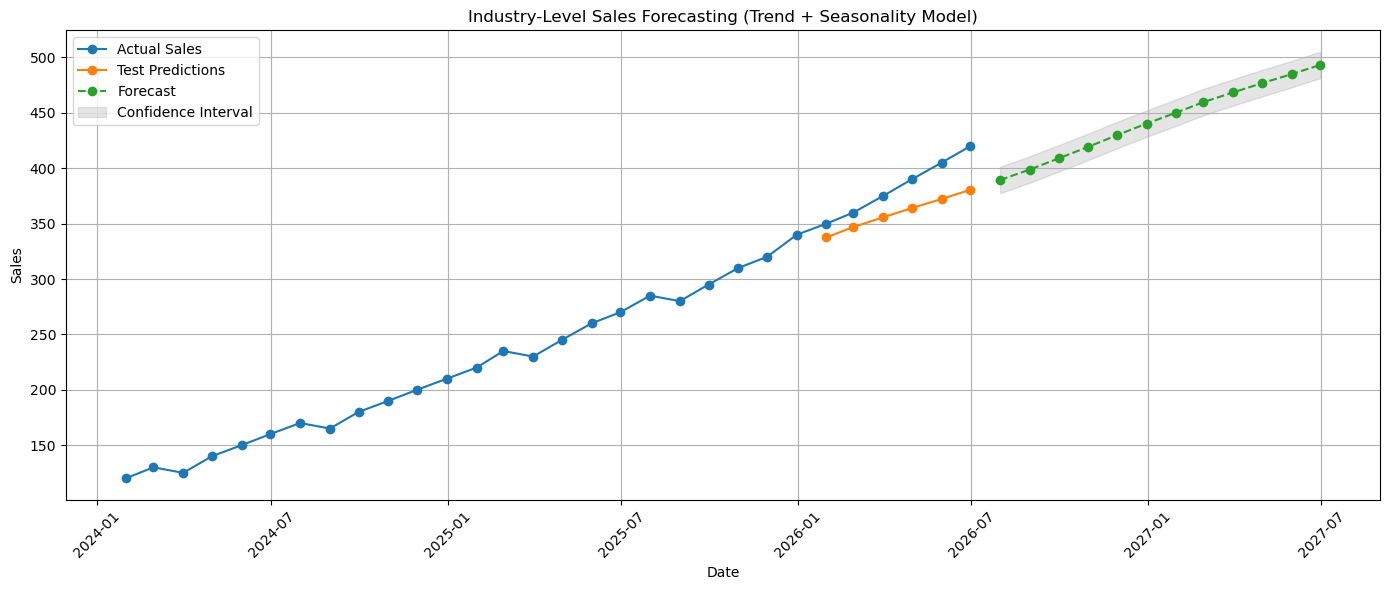

In [10]:
# ==============================
# 9. VISUALIZATION + SAVE GRAPH
# ==============================
plt.figure(figsize=(14,6))

# Actual sales
plt.plot(df["date"], df["sales"], label="Actual Sales", marker="o")

# Test predictions
plt.plot(test["date"], y_pred, label="Test Predictions", marker="o")

# Future forecast
plt.plot(future_dates, future_pred,
         label="Forecast",
         linestyle="dashed",
         marker="o")

# Confidence interval
plt.fill_between(
    future_dates,
    lower,
    upper,
    color="gray",
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Industry-Level Sales Forecasting (Trend + Seasonality Model)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()

# Save graph
plt.savefig("forecast_graph.png", dpi=300, bbox_inches="tight")

# Show graph
plt.show()

Display Forecast Values

In [11]:
print("Next 12 Months Sales Forecast")
print("--------------------------------")
print(future_df[["date", "Forecast"]])

Next 12 Months Sales Forecast
--------------------------------
         date    Forecast
0  2026-07-31  389.399768
1  2026-08-31  398.828684
2  2026-09-30  408.858599
3  2026-10-31  419.318736
4  2026-11-30  429.923040
5  2026-12-31  440.346824
6  2027-01-31  450.313775
7  2027-02-28  459.669986
8  2027-03-31  468.425197
9  2027-04-30  476.750186
10 2027-05-31  484.931008
11 2027-06-30  493.292350
